In [ ]:
!pip install snntorch mne torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snntorch as snn
from snntorch import spikeplot as splt
import torch
import matplotlib.pyplot as plt
from IPython.display import HTML
import torch.nn as nn
import itertools

In [ ]:
class SeizureSNN(nn.Module):
  def __init__(self,input,hidden,output):
    super().__init__()
    """
        64 -> 8 -> 1 LIF SNN

        Learnable parameters:
            fc1 : 64*8 + 8 = 520
            fc2 : 8*1 + 1 = 9
            -------------------
            Total = 529

        beta and threshold are fixed (not learnable).
    """
    self.fc1 = nn.Linear(input , hidden, bias = True)
    self.fc2 = nn.Linear(hidden , output ,bias = True)

    #lif1
    self.lif1 = snn.Leaky(beta = 0.9, threshold = 1.0, learn_beta=False, learn_threshold= False, reset_mechanism="subtract")
    self.lif2 = snn.Leaky(beta = 0.9, threshold = 1.0, learn_beta=False, learn_threshold= False, reset_mechanism="subtract")

  def forward(self,x):
    """
        x shape:
            (num_steps, batch_size, 64)

        Returns
        -------
        spk_rec : (num_steps, batch_size, 1)
        mem_rec : (num_steps, batch_size, 1)
    """
    mem1 = self.lif1.init_leaky()
    mem2 = self.lif2.init_leaky()

    spk_rec = []
    mem_rec = []

    num_steps = x.size(0)

    for step in range(num_steps):
      cur1 = self.fc1(x[step])
      spk1,mem1 = self.lif1(cur1,mem1)
      cur2 = self.fc2(spk1)
      spk2,mem2 = self.lif2(cur2,mem2)
      spk_rec.append(spk2)
      mem_rec.append(mem2)

    spk_rec = torch.stack(spk_rec)
    mem_rec = torch.stack(mem_rec)

    return spk_rec, mem_rec




In [ ]:
if __name__ == "__main__":

    model = SeizureSNN(64,8,1)

    # Sanity check 1
    total_params = sum(p.numel() for p in model.parameters())

    print(f"Total learnable params: {total_params}")
    print("Target: 529")

    # Sanity check 2
    num_steps = 50
    batch_size = 4

    dummy = torch.ones(num_steps, batch_size, 64) * 20

    model.train()
    spk, mem = model(dummy)

    print("Input shape :", dummy.shape)
    print("Spike shape :", spk.shape)
    print("Mem shape   :", mem.shape)

Total learnable params: 529
Target: 529
Input shape : torch.Size([50, 4, 64])
Spike shape : torch.Size([50, 4, 1])
Mem shape   : torch.Size([50, 4, 1])


# sample data view

In [ ]:
model.eval()
with torch.inference_mode():
  spk, mem = model(dummy)

print("spk shape:", spk.shape)   # (num_steps, batch_size, 1)
print("mem shape:", mem.shape)   # (num_steps, batch_size, 1)
print("\nstep | spike | membrane")
print("-" * 30)
for t in range(num_steps):
    spike_val = spk[t, 0, 0].item()
    mem_val = mem[t, 0, 0].item() #mem is a logit - not normalized raw potential -inf to +inf
    mem_prob = torch.sigmoid(mem[t, 0, 0]).item()
    print(f"{t:4d} | {spike_val:5.0f} | {mem_val:8.4f} | {mem_prob:8.4f}")

spk shape: torch.Size([50, 4, 1])
mem shape: torch.Size([50, 4, 1])

step | spike | membrane
------------------------------
   0 |     0 |   0.5269 |   0.6288
   1 |     1 |   1.3494 |   0.7940
   2 |     0 |   0.7413 |   0.6773
   3 |     1 |   1.5424 |   0.8238
   4 |     1 |   1.2633 |   0.7796
   5 |     0 |   0.6639 |   0.6601
   6 |     1 |   1.4727 |   0.8135
   7 |     0 |   0.8523 |   0.7010
   8 |     1 |   1.6422 |   0.8378
   9 |     1 |   1.3532 |   0.7947
  10 |     0 |   0.7448 |   0.6780
  11 |     1 |   1.5455 |   0.8243
  12 |     0 |   0.9178 |   0.7146
  13 |     1 |   1.7012 |   0.8457
  14 |     1 |   1.4063 |   0.8032
  15 |     0 |   0.7925 |   0.6884
  16 |     1 |   1.5885 |   0.8304
  17 |     0 |   0.9565 |   0.7224
  18 |     1 |   1.7360 |   0.8502
  19 |     1 |   1.4376 |   0.8081
  20 |     0 |   0.8207 |   0.6944
  21 |     1 |   1.6139 |   0.8339
  22 |     0 |   0.9794 |   0.7270
  23 |     1 |   1.7566 |   0.8528
  24 |     1 |   1.4561 |   0.8109
 

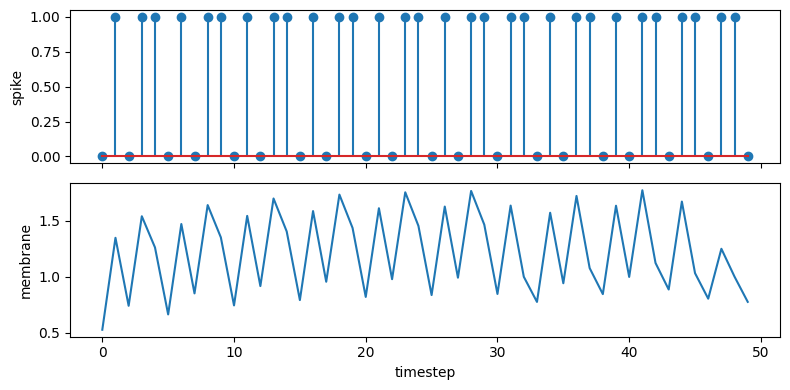

In [ ]:
import matplotlib.pyplot as plt

steps = range(num_steps)
spk_trace = spk[:, 0, 0].numpy()
mem_trace = mem[:, 0, 0].numpy()

fig, axs = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
axs[0].stem(steps, spk_trace)
axs[0].set_ylabel("spike")
axs[1].plot(steps, mem_trace)
axs[1].set_ylabel("membrane")
axs[1].set_xlabel("timestep")
plt.tight_layout()
plt.show()